In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
import ast
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

### Importar el dataset

In [309]:
data = pd.read_csv('./Data.csv',low_memory=False)

### Informacion de la data

In [310]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17087 entries, 0 to 17086
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   md5                         17087 non-null  object 
 1   sha1                        17087 non-null  object 
 2   file_extension              17087 non-null  object 
 3   EntryPoint                  17087 non-null  object 
 4   PEType                      17087 non-null  object 
 5   MachineType                 17087 non-null  object 
 6   magic_number                17087 non-null  object 
 7   bytes_on_last_page          17087 non-null  object 
 8   pages_in_file               17087 non-null  object 
 9   relocations                 17087 non-null  object 
 10  size_of_header              17087 non-null  object 
 11  min_extra_paragraphs        17087 non-null  object 
 12  max_extra_paragraphs        17087 non-null  object 
 13  init_ss_value               170

### Numero de columnas y filas

In [311]:
print("Shape", data.shape)
print("Filas", data.shape[0])
print("Columnas", data.shape[1])

Shape (17087, 77)
Filas 17087
Columnas 77


### Listar todas las columnas por tipo de varibale: categorica y numerica

In [312]:
# --- Detectar columnas categóricas ---
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()

print("Columnas categóricas:")
print(cat_cols)

Columnas categóricas:
['md5', 'sha1', 'file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rda

In [313]:
# --- Detectar columnas numericas ---
num_cols = data.select_dtypes(include=["float64"]).columns.tolist()

print("Columnas numericas:")
print(num_cols )

Columnas numericas:
['registry_read', 'registry_write', 'registry_delete', 'registry_total', 'network_threats', 'network_dns', 'network_http', 'network_connections', 'processes_malicious', 'processes_suspicious', 'processes_monitored', 'total_procsses', 'files_malicious', 'files_suspicious', 'files_text', 'files_unknown', 'dlls_calls', 'apis']


### Cantidad de  variables numericas y categoricas

In [314]:
data.dtypes.value_counts()


object     59
float64    18
Name: count, dtype: int64

### Ver los valores nulos

In [315]:
print("\n Conteo de valores nulos por columna:")
print(data.isnull().sum())


 Conteo de valores nulos por columna:
md5                           0
sha1                          0
file_extension                0
EntryPoint                    0
PEType                        0
MachineType                   0
magic_number                  0
bytes_on_last_page            0
pages_in_file                 0
relocations                   0
size_of_header                0
min_extra_paragraphs          0
max_extra_paragraphs          0
init_ss_value                 0
init_sp_value                 0
init_ip_value                 0
init_cs_value                 0
over_lay_number               0
oem_identifier                0
address_of_ne_header          0
Magic                         0
SizeOfCode                    0
SizeOfInitializedData         0
SizeOfUninitializedData       0
AddressOfEntryPoint           0
BaseOfCode                    0
BaseOfData                    0
ImageBase                     0
SectionAlignment              0
FileAlignment                 0
O

### Valores vacios por columna

In [316]:
# 4) Detectar valores vacíos (celdas con string vacío o solo espacios)
print("\n Conteo de valores vacíos por columna:")
print((data.applymap(lambda x: str(x).strip() == '')).sum())




 Conteo de valores vacíos por columna:


C:\Users\Dell\AppData\Local\Temp\ipykernel_26500\2919232096.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((data.applymap(lambda x: str(x).strip() == '')).sum())


md5                           0
sha1                          0
file_extension                0
EntryPoint                    0
PEType                        0
MachineType                   0
magic_number                  0
bytes_on_last_page            0
pages_in_file                 0
relocations                   0
size_of_header                0
min_extra_paragraphs          0
max_extra_paragraphs          0
init_ss_value                 0
init_sp_value                 0
init_ip_value                 0
init_cs_value                 0
over_lay_number               0
oem_identifier                0
address_of_ne_header          0
Magic                         0
SizeOfCode                    0
SizeOfInitializedData         0
SizeOfUninitializedData       0
AddressOfEntryPoint           0
BaseOfCode                    0
BaseOfData                    0
ImageBase                     0
SectionAlignment              0
FileAlignment                 0
OperatingSystemVersion        0
ImageVer

### Ver  filas vacias

In [317]:
# 5) Detectar filas completamente vacías
print("\n Número de filas completamente vacías:")
print(data.isnull().all(axis=1).sum())


 Número de filas completamente vacías:
0


In [318]:
# 6) Ver filas sospechosas (con valores nulos o vacíos en alguna columna)
print("\n Filas con valores nulos o vacíos:")
print(data[data.isnull().any(axis=1) | data.applymap(lambda x: str(x).strip() == '').any(axis=1)])


 Filas con valores nulos o vacíos:


C:\Users\Dell\AppData\Local\Temp\ipykernel_26500\3230463956.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(data[data.isnull().any(axis=1) | data.applymap(lambda x: str(x).strip() == '').any(axis=1)])


Empty DataFrame
Columns: [md5, sha1, file_extension, EntryPoint, PEType, MachineType, magic_number, bytes_on_last_page, pages_in_file, relocations, size_of_header, min_extra_paragraphs, max_extra_paragraphs, init_ss_value, init_sp_value, init_ip_value, init_cs_value, over_lay_number, oem_identifier, address_of_ne_header, Magic, SizeOfCode, SizeOfInitializedData, SizeOfUninitializedData, AddressOfEntryPoint, BaseOfCode, BaseOfData, ImageBase, SectionAlignment, FileAlignment, OperatingSystemVersion, ImageVersion, SizeOfImage, SizeOfHeaders, Checksum, Subsystem, DllCharacteristics, SizeofStackReserve, SizeofStackCommit, SizeofHeapCommit, SizeofHeapReserve, LoaderFlags, text_VirtualSize, text_VirtualAddress, text_SizeOfRawData, text_PointerToRawData, text_PointerToRelocations, text_PointerToLineNumbers, text_Characteristics, rdata_VirtualSize, rdata_VirtualAddress, rdata_SizeOfRawData, rdata_PointerToRawData, rdata_PointerToRelocations, rdata_PointerToLineNumbers, rdata_Characteristics, re

### Distribucion multiclase Bening, Ransoware y Trojan
Esta desbalanceada la clase

Distribución de clases:
 Category
Benign        10876
Ransomware     4762
Trojan         1449
Name: count, dtype: int64


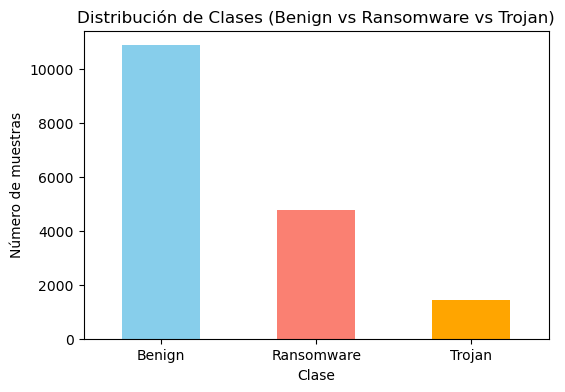

In [319]:
# Contar muestras por categoría
class_counts = data["Category"].value_counts()

# Imprimir valores exactos
print("Distribución de clases:\n", class_counts)

# Graficar
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar", color=["skyblue", "salmon", "orange"])
plt.title("Distribución de Clases (Benign vs Ransomware vs Trojan)")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(rotation=0)
plt.show()


### Definir features (X)
Ahora X contiene solo las características.

In [320]:
X = data.drop(columns=["Class", "Category", "Family"], errors="ignore")
print("Shape de X (features):", X.shape)

Shape de X (features): (17087, 74)


### Definir target

In [321]:
y = data["Category"] # multiclase: Benign, Ransomware, Trojan
print("Shape de y (target):", y.shape)

Shape de y (target): (17087,)


### Eliminacion de columnas que no aportan valor

In [322]:
# 3. Eliminar columnas que no aportan valor
# md5, sha1 identificador
# file_extension tipo de extension exe 
#  "text_PointerToRelocations", "text_PointerToLineNumbers", solo tiene 0
#   "rdata_PointerToRelocations", "rdata_PointerToLineNumbers", solo tiene 0
#magic number no aporta 
# No aporta magic debido a que solo tiene una categoria
#EntryPoint variable redundante con Addres of entrypoint
cols_drop = [
    "md5", "sha1","file_extension","network_threats", "Magic", "magic_number",
    "oem_identifier", "address_of_ne_header",
     "text_PointerToRelocations", "text_PointerToLineNumbers",
    "rdata_PointerToRelocations", "rdata_PointerToLineNumbers",
    "Class", "Category", "Family", "registry_total", "total_procsses", "OperatingSystemVersion", "ImageVersion",
    "files_malicious","files_suspicious",
   "files_text", "files_unknown","processes_malicious","processes_suspicious","processes_monitored"]
X = X.drop(columns=cols_drop, errors="ignore")
print("Shape de X después de eliminar columnas no útiles:", X.shape)



Shape de X después de eliminar columnas no útiles: (17087, 51)


In [323]:
print("Dataset limpio:", X.shape)
print("Columnas:", X.columns.tolist())


Dataset limpio: (17087, 51)
Columnas: ['EntryPoint', 'PEType', 'MachineType', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rdata_PointerToRawData', 'rdata_Characteristics', 'registry_read', 'registry_write', 'registry_delete', 'network_dns', 'network_http', 'network_connections', 'dlls_calls', 'apis']


### Renombrar variables 

In [324]:
# Mapeo de nombres largos a cortos
rename_map = {
    "Intel 386 or later, and compatibles": "Intel386",
    "AMD AMD64": "AMD64",
    "MachineType": "Unknown"  # por si aparece un valor raro como 'MachineType'
}

# Aplicar reemplazo en la columna MachineType
if "MachineType" in X.columns:
    X["MachineType"] = X["MachineType"].replace(rename_map)

print("Valores únicos después del renombrado:")
print(X["MachineType"].unique())



Valores únicos después del renombrado:
['AMD64' 'Intel386' 'Unknown (0)']


In [325]:
# Conteo de nulos por columna
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


In [326]:
# Reemplazar '0' por IMAGE_SUBSYSTEM_UNKNOWN
if "Subsystem" in X.columns:
    X["Subsystem"] = X["Subsystem"].replace("0", "IMAGE_SUBSYSTEM_UNKNOWN")

print("Categorías únicas después:", X["Subsystem"].unique())
print("Conteo actualizado:")
print(X["Subsystem"].value_counts())




Categorías únicas después: ['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CUI'
 'IMAGE_SUBSYSTEM_NATIVE' 'IMAGE_SUBSYSTEM_UNKNOWN']
Conteo actualizado:
Subsystem
IMAGE_SUBSYSTEM_WINDOWS_GUI    13169
IMAGE_SUBSYSTEM_WINDOWS_CUI     3487
IMAGE_SUBSYSTEM_UNKNOWN          341
IMAGE_SUBSYSTEM_NATIVE            90
Name: count, dtype: int64


### Verificar las variables con error

In [327]:
# Ver todas las filas que tienen ese valor
X[X["PEType"] == "Unknown (0x2000)"]


,EntryPoint,PEType,MachineType,bytes_on_last_page,pages_in_file,relocations,size_of_header,min_extra_paragraphs,max_extra_paragraphs,init_ss_value,...,rdata_PointerToRawData,rdata_Characteristics,registry_read,registry_write,registry_delete,network_dns,network_http,network_connections,dlls_calls,apis
999,0x0000,Unknown (0x2000),Intel386,0x0050,0x0002,0x0000,0x0004,0x000F,0xFFFF,0x0000,...,0x00013400,"['IMAGE_SCN_CNT_INITIALIZED_DATA', 'IMAGE_SCN_...",10.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
9655,0x2800a,Unknown (0x2000),Intel386,0x0050,0x0002,0x0000,0x0004,0x0000,0xFFFF,0x0000,...,0x00072200,"['IMAGE_SCN_CNT_INITIALIZED_DATA', 'IMAGE_SCN_...",0.0,0.0,1.0,0.0,0.0,12.0,0.0,338.0


### Eliminar filas que tienen errores

In [328]:
# === Eliminar filas con PEType = 'Unknown (0x2000)' ===
if "PEType" in X.columns:
    filas_iniciales = X.shape[0]
    mask = X["PEType"] != "Unknown (0x2000)"
    X = X[mask]
    y = y[mask]   # eliminar también en y
    print(f"Filas eliminadas (PEType): {filas_iniciales - X.shape[0]}")



Filas eliminadas (PEType): 2


In [329]:
# === Eliminar filas con MachineType = 'Unknown (0)' ===
filas_iniciales = X.shape[0]
if "MachineType" in X.columns:
    mask = X["MachineType"] != "Unknown (0)"
    X = X[mask]
    y = y[mask]   # eliminar también en y

filas_finales = X.shape[0]



In [330]:
print(f"Filas eliminadas (MachineType): {filas_iniciales - filas_finales}")
print(f"Shape final de X: {X.shape}")
print(f"Shape final de y: {y.shape}")
print("Valores únicos en MachineType:", X["MachineType"].unique())

Filas eliminadas (MachineType): 6
Shape final de X: (17079, 51)
Shape final de y: (17079,)
Valores únicos en MachineType: ['AMD64' 'Intel386']


### Limpieza de la variable AddressOfEntryPoint

In [331]:
def limpiar_hex_con_texto(val):
    if isinstance(val, str):
        val = val.strip()
        if val == "0":       # caso especial: valor 0
            return 0.0
        match = re.search(r"0x[0-9A-Fa-f]+", val)
        if match:
            try:
                return float(int(match.group(0), 16))
            except:
                return np.nan
        return np.nan
    return val
if "AddressOfEntryPoint" in X.columns:
    X["AddressOfEntryPoint"] = (
        X["AddressOfEntryPoint"]
        .map(limpiar_hex_con_texto)
        .astype("float64")
    )
    print("Columna AddressOfEntryPoint corregida sin convertir los '0' a NaN.")
    print("Nulos restantes:", X["AddressOfEntryPoint"].isnull().sum())


Columna AddressOfEntryPoint corregida sin convertir los '0' a NaN.
Nulos restantes: 0


In [332]:
# Conteo de nulos por columna
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


### Convertir las variables  hexadecimales a float


In [333]:

# === 1) Define las categóricas que NO deben tocarse ===
CATEGORICAS_EXCLUIR = [
    "MachineType", "Subsystem", "PEType",
    "DllCharacteristics", "text_Characteristics", "rdata_Characteristics"
]
cat_presentes = [c for c in CATEGORICAS_EXCLUIR if c in X.columns]

# === 2) Funciones auxiliares ===
HEX_REGEX = re.compile(r"^\s*0[xX][0-9A-Fa-f]+\s*$")

def es_hex(s: str) -> bool:
    return isinstance(s, str) and bool(HEX_REGEX.match(s.strip()))

def parsear_num(val):
    """Convierte hex ('0x...') o decimal en texto a float64. Si falla -> NaN."""
    if isinstance(val, str):
        s = val.strip()
        if es_hex(s):
            try:
                return float(int(s, 16))
            except:
                return np.nan
        try:
            return float(s)
        except:
            return np.nan
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

# === 3) Detectar columnas 'object' con al menos un valor hexadecimal ===
hex_cols = []
for col in X.select_dtypes(include=["object"]).columns:
    if col in cat_presentes:
        continue  # excluye categóricas
    muestra = X[col].dropna().astype(str)
    if muestra.map(es_hex).any():
      hex_cols.append(col)
print("Columnas detectadas con valores hexadecimales:", hex_cols)

# === 4) Convertir SOLO esas columnas a float64 ===
for col in hex_cols:
    X[col] = X[col].map(parsear_num).astype("float64")

# (Opcional) Verificación
print(X[hex_cols].dtypes if hex_cols else "No se detectaron columnas hexadecimales.")

# === 5) Exportar a CSV ===
output_path = "dataset_valoresfloat3.csv"
X.to_csv(output_path, index=False, encoding="utf-8")
print(f"Archivo exportado a: {output_path}")


Columnas detectadas con valores hexadecimales: ['EntryPoint', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rdata_PointerToRawData']
EntryPoint                 float64
bytes_on_last_page         float64
pages_in_file              float64
relocations                float64
size_of_header             float64
min_extra_paragraphs       float64
max_extra_paragraphs       float64
init_ss_value  

In [334]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17079 entries, 0 to 17086
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EntryPoint               17079 non-null  float64
 1   PEType                   17079 non-null  object 
 2   MachineType              17079 non-null  object 
 3   bytes_on_last_page       17079 non-null  float64
 4   pages_in_file            17079 non-null  float64
 5   relocations              17079 non-null  float64
 6   size_of_header           17079 non-null  float64
 7   min_extra_paragraphs     17079 non-null  float64
 8   max_extra_paragraphs     17079 non-null  float64
 9   init_ss_value            17079 non-null  float64
 10  init_sp_value            17079 non-null  float64
 11  init_ip_value            17079 non-null  float64
 12  init_cs_value            17079 non-null  float64
 13  over_lay_number          17079 non-null  float64
 14  SizeOfCode               17

### Revisar la cardinalidad de las variables categoricas
Para ver si se aplica one-hot Encoder o Label Enconder. 
One-hot Se aplica a variables que tenga pocas categorias
Label Encoder 
Ventajas no crea varias columnas Útil para modelos que no interpretan los números como un orden (ej. árboles: Decision Tree, Random Forest, XGBoost, LightGBM). 
Todas esas variables estan categorizadas como object, en las cuales algunas eran object y otras eran hexcd que estans como object


In [335]:
# --- Revisar cardinalidad (número de valores únicos) ---
cat_cardinalidad = {c: data[c].nunique() for c in cat_cols}
print("\nCardinalidad de columnas categóricas:")
for col, nunique in cat_cardinalidad.items():
    print(f"{col}: {nunique}")


Cardinalidad de columnas categóricas:
md5: 9855
sha1: 9856
file_extension: 1
EntryPoint: 6191
PEType: 3
MachineType: 3
magic_number: 2
bytes_on_last_page: 64
pages_in_file: 63
relocations: 43
size_of_header: 43
min_extra_paragraphs: 42
max_extra_paragraphs: 40
init_ss_value: 40
init_sp_value: 46
init_ip_value: 52
init_cs_value: 52
over_lay_number: 49
oem_identifier: 47
address_of_ne_header: 69
Magic: 3
SizeOfCode: 2488
SizeOfInitializedData: 2204
SizeOfUninitializedData: 404
AddressOfEntryPoint: 5908
BaseOfCode: 336
BaseOfData: 942
ImageBase: 99
SectionAlignment: 9
FileAlignment: 8
OperatingSystemVersion: 21
ImageVersion: 98
SizeOfImage: 1997
SizeOfHeaders: 24
Checksum: 3621
Subsystem: 5
DllCharacteristics: 57
SizeofStackReserve: 57
SizeofStackCommit: 42
SizeofHeapCommit: 10
SizeofHeapReserve: 22
LoaderFlags: 4
text_VirtualSize: 5553
text_VirtualAddress: 121
text_SizeOfRawData: 2143
text_PointerToRawData: 124
text_PointerToRelocations: 6
text_PointerToLineNumbers: 12
text_Characterist

### Convertir las variables categoricas
Hay 6 variables categoricas
One-Hot Encoding a MachineType, Subsystem, PEType.

Multi-Label Binarization a DllCharacteristics, text_Characteristics, rdata_Characteristics.

In [336]:
# === Variables categóricas ===
categorical_single = ["MachineType", "Subsystem", "PEType"]  # One-Hot Encoding
categorical_multi  = ["DllCharacteristics", "text_Characteristics", "rdata_Characteristics"]  # Multi-Label Binarization

# === 1. Categorías simples (One-Hot) ===
for col in categorical_single:
    if col in X.columns:
        print(f"\n▶ {col} (categorías únicas):")
        print(X[col].unique())

# === 2. Categorías multilabel ===
for col in categorical_multi:
    if col in X.columns:
        print(f"\n▶ {col} (categorías posibles):")
        categorias = set()
        for row in X[col].dropna():
            if isinstance(row, str):
                try:
                    # Convierte el string de lista a lista real
                    items = ast.literal_eval(row)
                    categorias.update(items)
                except:
                    pass
        print(sorted(categorias))
        print(f"Total categorías en {col}: {len(categorias)}")



▶ MachineType (categorías únicas):
['AMD64' 'Intel386']

▶ Subsystem (categorías únicas):
['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CUI'
 'IMAGE_SUBSYSTEM_NATIVE' 'IMAGE_SUBSYSTEM_UNKNOWN']

▶ PEType (categorías únicas):
['PE32+' 'PE32']

▶ DllCharacteristics (categorías posibles):
['IMAGE_DLLCHARACTERISTICS_APPCONTAINER', 'IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE', 'IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY', 'IMAGE_DLLCHARACTERISTICS_GUARD_CF', 'IMAGE_DLLCHARACTERISTICS_HIGH_ENTROPY_VA', 'IMAGE_DLLCHARACTERISTICS_NO_BIND', 'IMAGE_DLLCHARACTERISTICS_NO_ISOLATION', 'IMAGE_DLLCHARACTERISTICS_NO_SEH', 'IMAGE_DLLCHARACTERISTICS_NX_COMPAT', 'IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE', 'IMAGE_LIBRARY_PROCESS_INIT', 'IMAGE_LIBRARY_PROCESS_TERM', 'IMAGE_LIBRARY_THREAD_INIT']
Total categorías en DllCharacteristics: 13

▶ text_Characteristics (categorías posibles):
['IMAGE_SCN_ALIGN_1024BYTES', 'IMAGE_SCN_ALIGN_128BYTES', 'IMAGE_SCN_ALIGN_16BYTES', 'IMAGE_SCN_ALIGN_1BYTES', 'IMA

### Aplicacion de one Hot Encoder
Variables: 
MachineType,  
Subsystem
PEType

In [337]:

# Variables categóricas de una sola categoría por fila
categorical_single = ["MachineType", "Subsystem", "PEType"]

# Crear el encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Ajustar y transformar sobre X
encoded_array = ohe.fit_transform(X[categorical_single])

# Convertir a DataFrame con nombres de columnas
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=ohe.get_feature_names_out(categorical_single), 
    index=X.index
)

# Concatenar al dataset original, eliminando las columnas viejas
X = pd.concat([X.drop(columns=categorical_single), encoded_df], axis=1)

# (opcional) optimizar memoria: pasar a uint8 en vez de float64
X[encoded_df.columns] = X[encoded_df.columns].astype("uint8")

# Verificación
print("Shape final de X:", X.shape)
print("Columnas nuevas:", encoded_df.columns.tolist())
print("Categóricas que quedan:", X.select_dtypes(include="object").columns.tolist())



Shape final de X: (17079, 56)
Columnas nuevas: ['MachineType_AMD64', 'MachineType_Intel386', 'Subsystem_IMAGE_SUBSYSTEM_NATIVE', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI', 'PEType_PE32', 'PEType_PE32+']
Categóricas que quedan: ['DllCharacteristics', 'text_Characteristics', 'rdata_Characteristics']


### Aplicar Multi-Label Binarization
DllCharacteristics', 'text_Characteristics', 'rdata_Characteristics

In [338]:
multilabel_cols = ["DllCharacteristics", "text_Characteristics", "rdata_Characteristics"]
multilabel_cols = [c for c in multilabel_cols if c in X.columns]

def _to_list(cell):
    """Convierte celda a lista de strings limpia."""
    if isinstance(cell, list):
        return [str(x).strip() for x in cell if str(x).strip() != ""]
    if isinstance(cell, str):
        s = cell.strip()
        if s == "" or s.upper() in {"NAN", "NONE", "NULL"}:
            return []
        # casos como "[]", "['A', 'B']"
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return [str(x).strip() for x in parsed if str(x).strip() != ""]
            return [s] if s != "" else []
        except Exception:
            return [s]
    # NaN u otros tipos
    return []

nuevas_cols_totales = []

for col in multilabel_cols:
    listas = X[col].apply(_to_list)

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(listas)

    prefijo = f"{col}_"
    cols_out = [prefijo + cls for cls in mlb.classes_]
    encoded_df = pd.DataFrame(encoded, columns=cols_out, index=X.index)

    # <<< CLAVE: asegurar 0/1 sin vacíos >>>
    encoded_df = encoded_df.fillna(0).astype("uint8")

    # concatenar y eliminar la original
    X = pd.concat([X.drop(columns=[col]), encoded_df], axis=1)
    nuevas_cols_totales.extend(cols_out)

    print(f"{col}: {len(cols_out)} columnas creadas (sin NaN).")

print("\nTotal de columnas nuevas (multilabel):", len(nuevas_cols_totales))
print("Columnas object restantes:", X.select_dtypes(include="object").columns.tolist())


DllCharacteristics: 14 columnas creadas (sin NaN).
text_Characteristics: 38 columnas creadas (sin NaN).
rdata_Characteristics: 39 columnas creadas (sin NaN).

Total de columnas nuevas (multilabel): 91
Columnas object restantes: []


In [339]:
print("Columnas object restantes:", X.select_dtypes(include="object").columns.tolist())


Columnas object restantes: []


In [340]:
# Conteo de valores nulos por columna
print(X.isnull().sum())


EntryPoint                                                           0
bytes_on_last_page                                                   0
pages_in_file                                                        0
relocations                                                          0
size_of_header                                                       0
min_extra_paragraphs                                                 0
max_extra_paragraphs                                                 0
init_ss_value                                                        0
init_sp_value                                                        0
init_ip_value                                                        0
init_cs_value                                                        0
over_lay_number                                                      0
SizeOfCode                                                           0
SizeOfInitializedData                                                0
SizeOf

In [341]:
# === Exportar X a CSV ===
#X.to_csv("dataset_final.csv", index=False, encoding="utf-8")

#print("Archivo CSV guardado como: dataset_final.csv")

### Seleccion de caracteristicas
Los métodos de selección de características se pueden clasificar en tres categorías generales:

Métodos de filtrado: Los métodos de filtrado utilizan técnicas estadísticas para evaluar la relevancia de las características independientemente del modelo. Entre las técnicas más comunes se incluyen los coeficientes de correlación, las pruebas de chi-cuadrado y la información mutua.

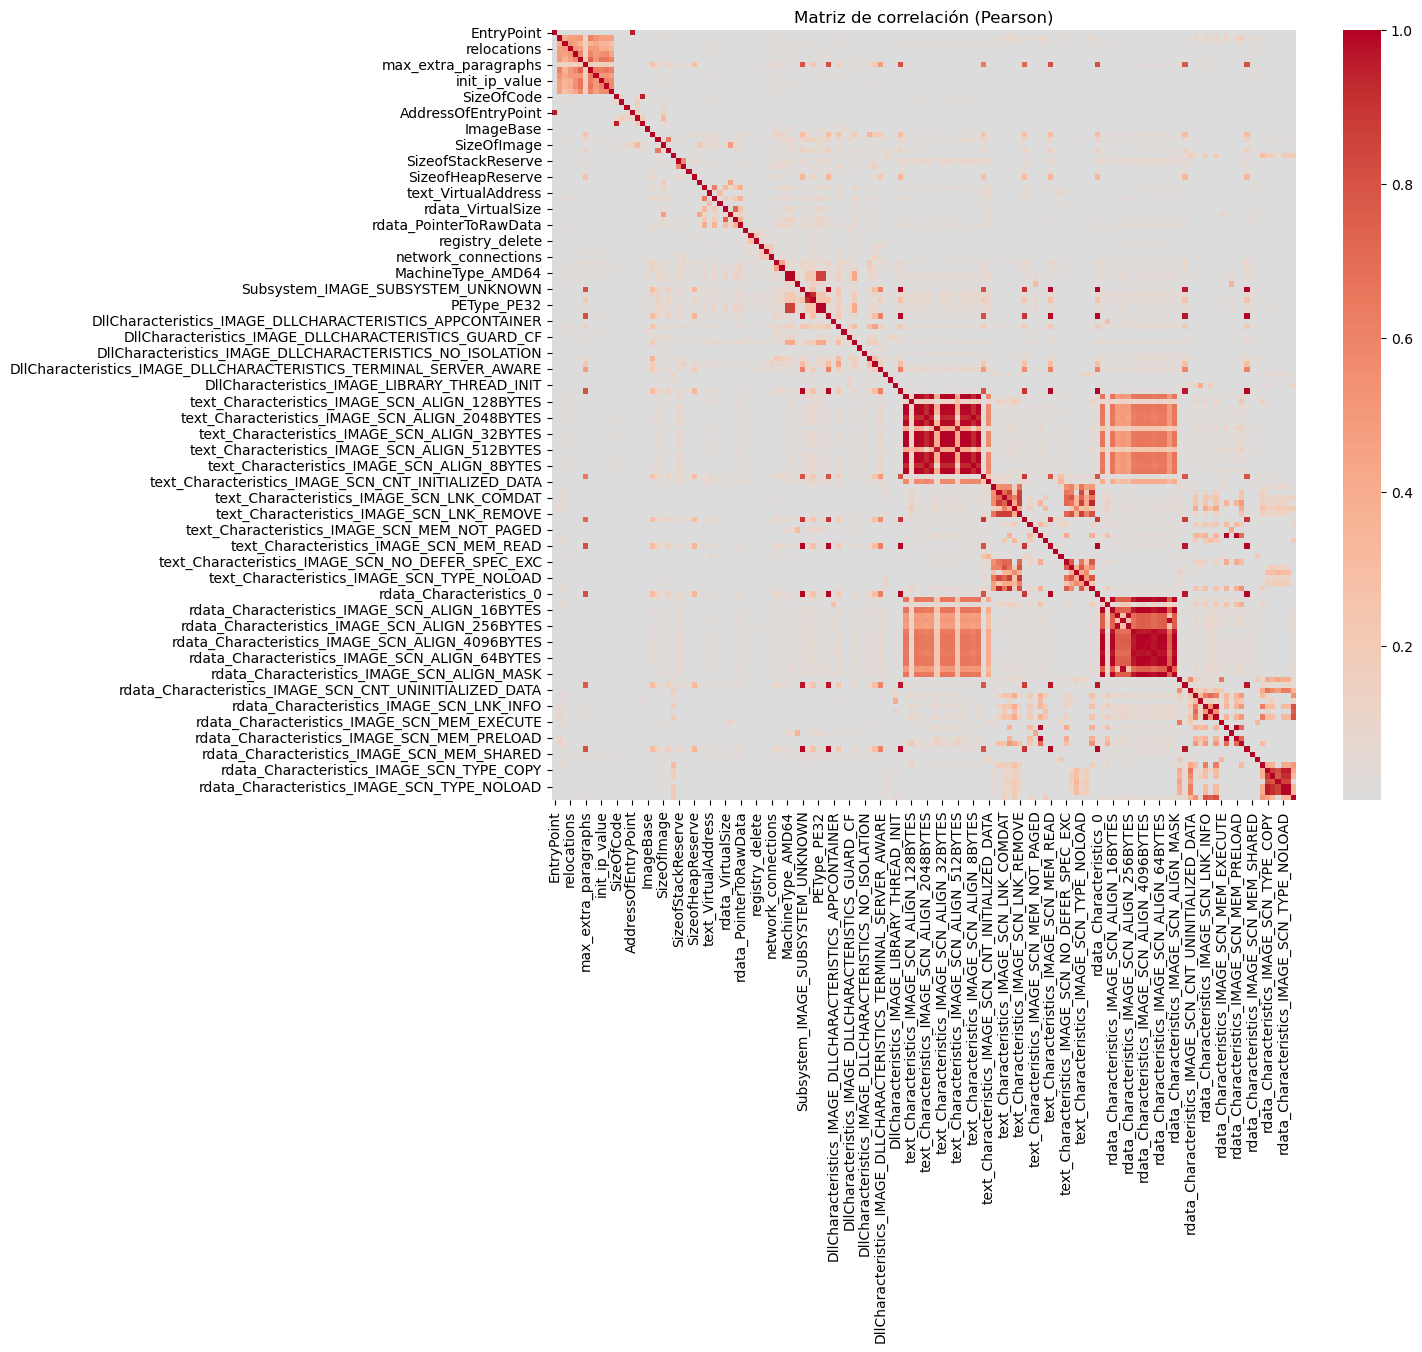

In [342]:

# === 1. Calcular matriz de correlación (Pearson) ===
corr_matrix = X.corr(method="pearson").abs()

# === 2. Visualización opcional ===
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (Pearson)")
plt.show()




In [343]:

# === 3. Mantener solo parte superior de la matriz (para evitar duplicados)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# === 4. Definir umbral (ejemplo: 0.95)
umbral = 0.95

# === 5. Detectar pares de columnas altamente correlacionadas
correlated_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > umbral
]

# === 6. Mostrar resultados
print(f"Número de pares de columnas con correlación > {umbral}: {len(correlated_pairs)}")
print("Ejemplos de pares correlacionados:")
for pair in correlated_pairs:
    print(pair)




Número de pares de columnas con correlación > 0.95: 125
Ejemplos de pares correlacionados:
('AddressOfEntryPoint', 'EntryPoint', 0.9594593038095964)
('MachineType_Intel386', 'MachineType_AMD64', 0.9999999999999999)
('PEType_PE32+', 'PEType_PE32', 1.0000000000000004)
('DllCharacteristics_0', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 0.9969862284523479)
('text_Characteristics_0', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 0.9969862284523479)
('text_Characteristics_0', 'DllCharacteristics_0', 1.0)
('text_Characteristics_IMAGE_SCN_ALIGN_16BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_1024BYTES', 1.0)
('text_Characteristics_IMAGE_SCN_ALIGN_1BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_1024BYTES', 0.9881959356711576)
('text_Characteristics_IMAGE_SCN_ALIGN_1BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_16BYTES', 0.9881959356711576)
('text_Characteristics_IMAGE_SCN_ALIGN_256BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_1024BYTES', 0.9881959356711576)
('text_Characteristics_IMAGE_SCN_ALIGN_256BYTES', 'te

### F-Test
Aplica ANOVA F-test entre cada feature y la variable objetivo y.

Muestra si la relación es estadísticamente significativa (p < 0.05) o no.

In [344]:

def calcular_f_test_y_pvalues(X, y, alpha=0.05):
    # Asegurarse de tomar solo variables numéricas
    X_num = X.select_dtypes(include=[np.number])
    
    # Calcular F-test
    F, p = f_classif(X_num, y)
    
    resultados = []
    for feature, f_val, p_val in zip(X_num.columns, F, p):
        if p_val < alpha:
            resultados.append(f"La variable {feature} es linealmente DEPENDIENTE de la clase. p-value: {p_val:.2e}")
        else:
            resultados.append(f"La variable {feature} es linealmente INDEPENDIENTE de la clase. p-value: {p_val:.2e}")
    
    return resultados

# === Ejecución ===
resultados = calcular_f_test_y_pvalues(X, y)

for r in resultados:  
    print(r)


La variable EntryPoint es linealmente DEPENDIENTE de la clase. p-value: 3.94e-03
La variable bytes_on_last_page es linealmente DEPENDIENTE de la clase. p-value: 3.73e-04
La variable pages_in_file es linealmente DEPENDIENTE de la clase. p-value: 1.57e-07
La variable relocations es linealmente DEPENDIENTE de la clase. p-value: 9.38e-04
La variable size_of_header es linealmente DEPENDIENTE de la clase. p-value: 6.96e-03
La variable min_extra_paragraphs es linealmente DEPENDIENTE de la clase. p-value: 8.13e-06
La variable max_extra_paragraphs es linealmente DEPENDIENTE de la clase. p-value: 0.00e+00
La variable init_ss_value es linealmente DEPENDIENTE de la clase. p-value: 1.24e-06
La variable init_sp_value es linealmente DEPENDIENTE de la clase. p-value: 9.99e-04
La variable init_ip_value es linealmente DEPENDIENTE de la clase. p-value: 9.43e-04
La variable init_cs_value es linealmente DEPENDIENTE de la clase. p-value: 6.54e-04
La variable over_lay_number es linealmente DEPENDIENTE de la 

### Mutual Information
Mientras más alto el MI_score, más información aporta la variable para predecir la clase.

In [345]:


# === 1. Calcular Mutual Information ===
mi_scores = mutual_info_classif(X, y, random_state=42)

# === 2. Crear DataFrame con resultados ===
df_mi = pd.DataFrame({
    "Feature": X.columns,
    "MI_score": mi_scores
}).sort_values(by="MI_score", ascending=False)

# === 3. Mostrar TODAS las filas en consola ===
pd.set_option("display.max_rows", None)
print(df_mi)




                                               Feature  MI_score
33                                   rdata_VirtualSize  0.625415
29                                    text_VirtualSize  0.609566
15                                 AddressOfEntryPoint  0.573187
0                                           EntryPoint  0.556851
13                               SizeOfInitializedData  0.488216
36                              rdata_PointerToRawData  0.470053
31                                  text_SizeOfRawData  0.426768
12                                          SizeOfCode  0.426313
21                                         SizeOfImage  0.409849
37                                       registry_read  0.364286
34                                rdata_VirtualAddress  0.318854
35                                 rdata_SizeOfRawData  0.317774
44                                                apis  0.310991
17                                          BaseOfData  0.269902
23                       

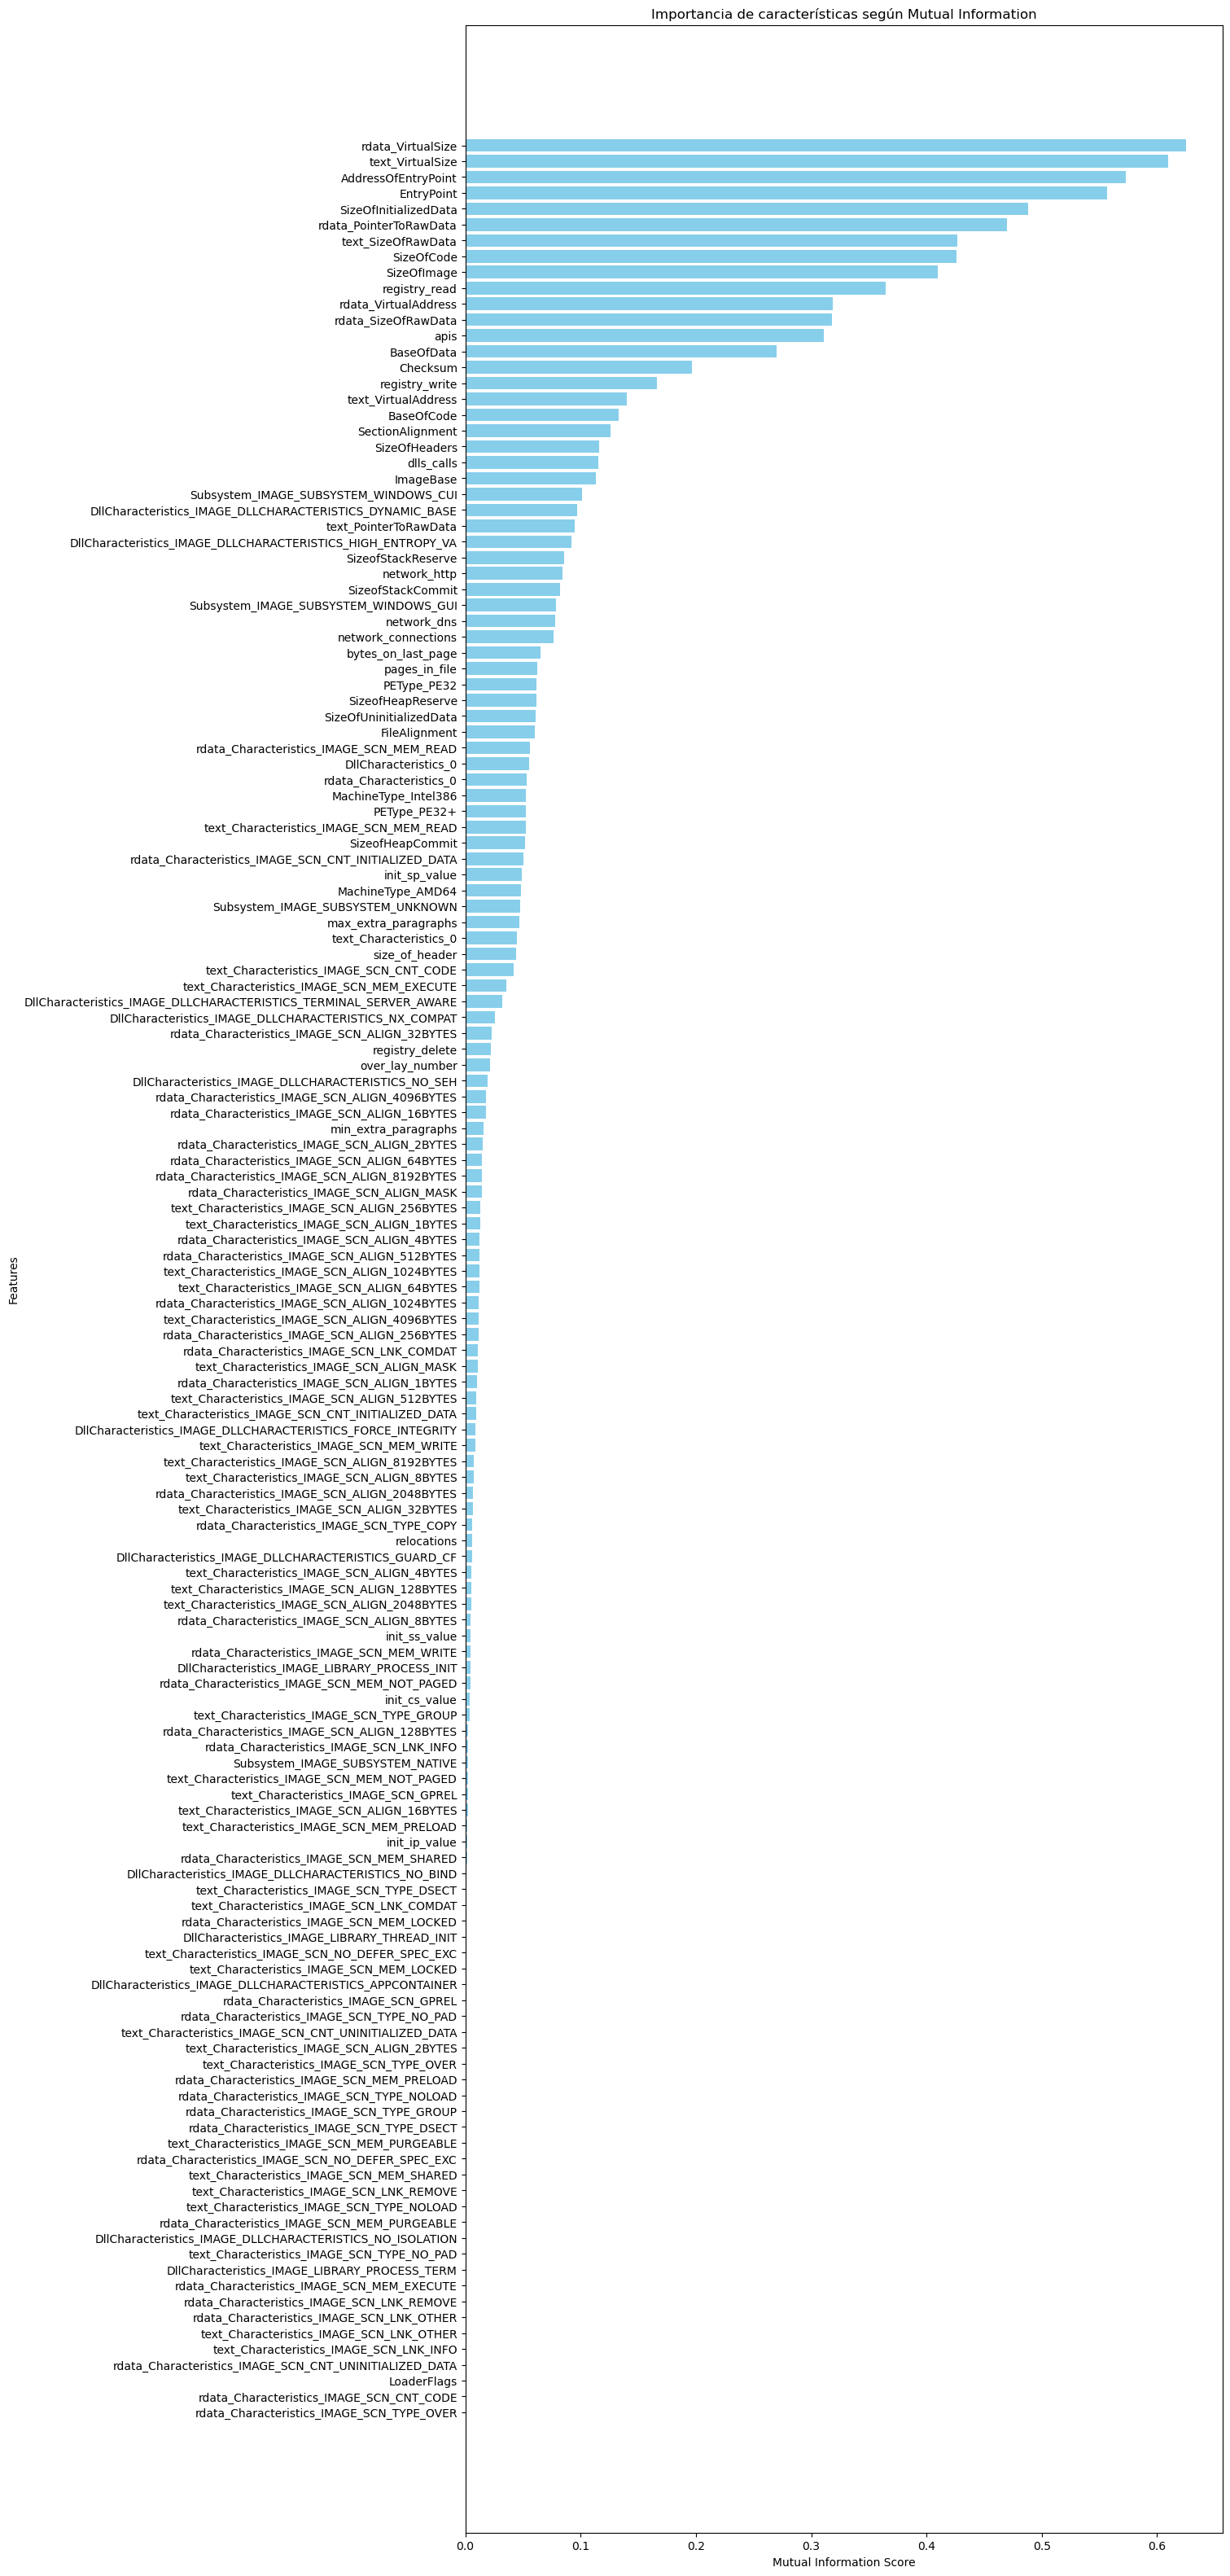

In [346]:
# === Gráfico de barras con todas las características ===
plt.figure(figsize=(12, 40))  # alto grande para que entren todas
plt.barh(df_mi["Feature"], df_mi["MI_score"], color="skyblue")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Importancia de características según Mutual Information")
plt.gca().invert_yaxis()  # para que las más altas queden arriba
plt.show()


### Chi-Cuadradotest 
Chi-cuadrado (χ²) se usa principalmente cuando las variables son categóricas o discretas (incluyendo binarias como 0/1)

In [347]:
# === 1. Detectar variables binarias (solo 0 y 1) ===
binarias = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0, 1})]

# Crear nuevo DataFrame solo con variables categóricas/binarias
X_bin = X[binarias].copy().astype(int)

print(f"Variables seleccionadas para Chi²: {binarias}")

# === 2. Calcular Chi² ===
chi_scores, p_values = chi2(X_bin, y)

# === 3. DataFrame con resultados + interpretación ===
chi2_results = pd.DataFrame({
    "Feature": X_bin.columns,
    "Chi2_score": chi_scores,
    "p_value": p_values,
    "Relacion_con_clase": [
        "DEPENDIENTE (p < 0.05)" if p < 0.05 else "INDEPENDIENTE (p >= 0.05)"
        for p in p_values
    ]
}).sort_values(by="Chi2_score", ascending=False)

# === 4. Mostrar tabla ===
print("\n=== Resultados Chi² (solo variables categóricas/binarias) ===")
print(chi2_results)

# === 5. Mostrar mensajes detallados por variable ===
print("\n=== Interpretación variable por variable ===")
for feature, chi, p in zip(X_bin.columns, chi_scores, p_values):
    if p < 0.05:
        print(f"La variable '{feature}' es DEPENDIENTE de la clase (p={p:.4e}, Chi²={chi:.2f})")
    else:
        print(f"La variable '{feature}' es INDEPENDIENTE de la clase (p={p:.4e}, Chi²={chi:.2f})")


Variables seleccionadas para Chi²: ['MachineType_AMD64', 'MachineType_Intel386', 'Subsystem_IMAGE_SUBSYSTEM_NATIVE', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI', 'PEType_PE32', 'PEType_PE32+', 'DllCharacteristics_0', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_APPCONTAINER', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_GUARD_CF', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_HIGH_ENTROPY_VA', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_BIND', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_ISOLATION', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_SEH', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NX_COMPAT', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE', 'DllCharacteristics_IMAGE_LIBRARY_PROCESS_INIT', 'DllCharacteristics_IMAGE_LIBRARY_PROCESS_TERM', 'DllCharacteri

### Eliminacion de variables parte 2 

In [348]:
# Lista de variables a eliminar según Pearson, F-test, Chi²
vars_a_eliminar = [
    "LoaderFlags",
    "BaseOfCode",
    "BaseOfData",
    "ImageBase",
    "AddressOfEntryPoint",
   "text_Characteristics_IMAGE_SCN_ALIGN_128BYTES",
    "rdata_Characteristics_IMAGE_SCN_ALIGN_128BYTES",
    "rdata_Characteristics_IMAGE_SCN_MEM_LOCKED",
    "rdata_Characteristics_IMAGE_SCN_MEM_PRELOAD",
    "rdata_Characteristics_IMAGE_SCN_MEM_PURGEABLE",
    "rdata_Characteristics_IMAGE_SCN_TYPE_GROUP",
    "text_Characteristics_IMAGE_SCN_MEM_PRELOAD",
    "text_Characteristics_IMAGE_SCN_MEM_PURGEABLE",
    "text_Characteristics_IMAGE_SCN_MEM_SHARED",
    "rdata_Characteristics_IMAGE_SCN_LNK_OTHER"
]
# Crear nuevo dataset filtrado
X = X.drop(columns=vars_a_eliminar, errors="ignore")

print(f"Dataset original: {X.shape[1]} variables")
print(f"Variables eliminadas: {len(vars_a_eliminar)}")
print(f"Dataset final: {X.shape[1]} variables")


Dataset original: 129 variables
Variables eliminadas: 15
Dataset final: 129 variables


### Balanceo de clases

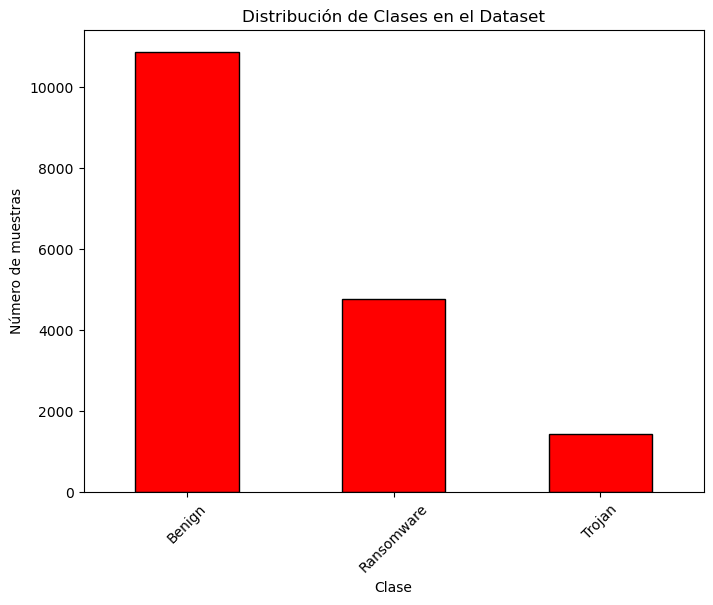

In [349]:

# Contar las clases
class_counts = y.value_counts()

# Gráfico de barras
plt.figure(figsize=(8,6))
class_counts.plot(kind='bar', color='red', edgecolor='black')

plt.title("Distribución de Clases en el Dataset")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45)
plt.show()


### Conversion a label encoder de la variable objetivo

In [350]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

print(le.classes_)  
# ['Benign' 'Ransomware' 'Trojan']


['Benign' 'Ransomware' 'Trojan']


In [351]:
print(y.head(10))     # originales
print(y_enc[:10])     # convertidos


0    Benign
1    Benign
2    Benign
3    Benign
4    Benign
5    Benign
6    Benign
7    Benign
8    Benign
9    Benign
Name: Category, dtype: object
[0 0 0 0 0 0 0 0 0 0]


### Dividir el conjunto de train/test

In [352]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_enc, test_size = 0.20, random_state=42, stratify=y_enc)


In [353]:
# Si quieres solo tamaños:
print("\nTamaños de los conjuntos:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Tamaños de los conjuntos:
X_train: (13663, 129)
y_train: (13663,)
X_test: (3416, 129)
y_test: (3416,)


### Aplicar submuestreo (Undersampling) 

In [354]:
# Conteo original
conteo = Counter(y_train)
print("Distribución original:", conteo)

# Queremos llevar todas las clases al nivel de Trojan (clase 2)
min_count = conteo[2]

rus = RandomUnderSampler(
    sampling_strategy={0: min_count, 1: min_count, 2: min_count},
    random_state=42
)

X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)
print("Después del undersampling uniforme:", Counter(y_train_bal))


Distribución original: Counter({0: 8694, 1: 3810, 2: 1159})
Después del undersampling uniforme: Counter({0: 1159, 1: 1159, 2: 1159})


### Grafico

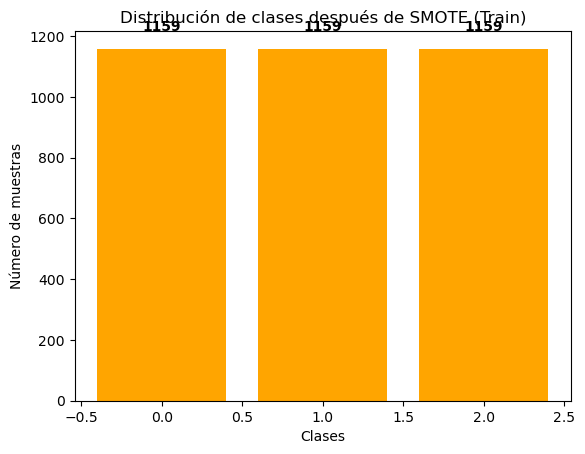

In [355]:

from collections import Counter
import matplotlib.pyplot as plt

# Contar clases después de SMOTE
class_counts = Counter(y_train_bal)

# Gráfico
plt.bar(class_counts.keys(), class_counts.values(), color="orange")
plt.title("Distribución de clases después de SMOTE (Train)")
plt.xlabel("Clases")
plt.ylabel("Número de muestras")

# Mostrar valores encima de cada barra
for clase, count in class_counts.items():
    plt.text(clase, count + 50, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

### Escalado de datos

In [356]:
# 3. Escalado (después del balanceo)
# =====================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)  # usa solo train para aprender media/var
X_test_scaled  = scaler.transform(X_test)           # aplica al test con los mismos parámetros

### Entrenamiento del modelo  con Logist Regression

In [357]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
    multi_class="ovr"
)
model.fit(X_train_scaled, y_train_bal)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'ovr'


### Evaluar el modelo


In [358]:
# Predicciones
y_pred = model.predict(X_test_scaled)

In [359]:

print("Accuracy global:", accuracy_score(y_test, y_pred))
print("\nEvaluacion del modelo:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy global: 0.8079625292740047

Evaluacion del modelo:
               precision    recall  f1-score   support

      Benign       0.98      0.79      0.88      2174
  Ransomware       0.69      0.84      0.76       952
      Trojan       0.46      0.80      0.58       290

    accuracy                           0.81      3416
   macro avg       0.71      0.81      0.74      3416
weighted avg       0.86      0.81      0.82      3416



### Metricas de evaluacion

### Matriz de confusion

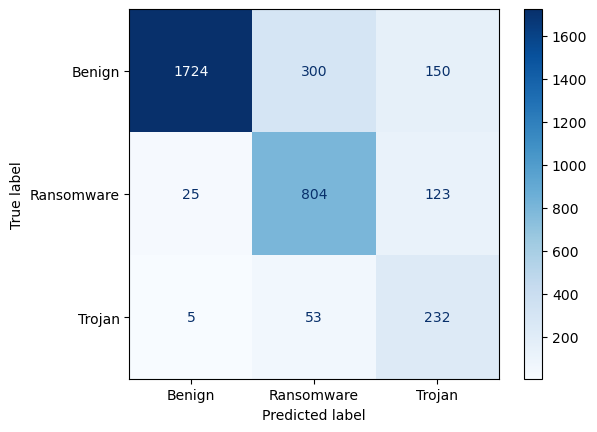

In [360]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")


### Curva Roc y el AUC por clase

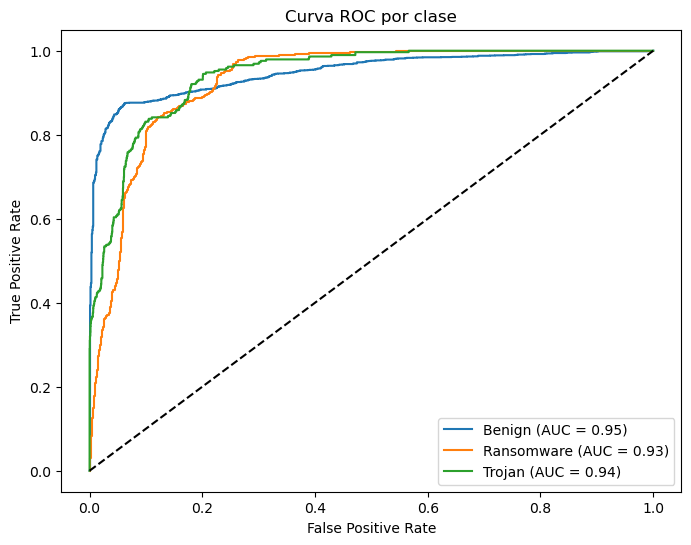

In [361]:

# Binarizamos las etiquetas reales (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0,1,2])  # 3 clases
y_pred_prob = model.predict_proba(X_test_scaled)      # <-- corregido

# Calcular ROC y AUC para cada clase
fpr = {}
tpr = {}
roc_auc = {}
for i in range(3):  # para cada clase
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar curvas ROC
plt.figure(figsize=(8,6))
for i, clase in enumerate(le.classes_):
    plt.plot(fpr[i], tpr[i], label=f"{clase} (AUC = {roc_auc[i]:.2f})")

# Línea diagonal (modelo aleatorio)
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC por clase")
plt.legend(loc="lower right")
plt.show()


### Cross-Validation

In [362]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),   # Escalado DENTRO del CV
    ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

scores = cross_val_score(pipeline, X, y_enc, cv=5, scoring="accuracy")
print("Accuracies CV:", scores)
print("Accuracy promedio CV:", scores.mean())


Accuracies CV: [0.84045667 0.80064403 0.65925059 0.7543911  0.71303075]
Accuracy promedio CV: 0.7535546270928984
